# Classical Melting-Layer (ML) Algorithm

This notebook implements a classical, physics-based ML detector using Ku/Ka DFR (Dual-Frequency Ratio) and reflectivity structure to identify bright-band melting layers in GPM DPR data.

In [14]:
# Configuration and imports
import os, json, math
import numpy as np
import matplotlib.pyplot as plt
import importlib
import h5py

import dgx_ml as dgx
# Reload to ensure latest helpers
dgx = importlib.reload(dgx)

data_cfg = {
    'DATA_DIR': 'GPM_DPR_2024',
    'FILE_GLOB': '**/*.HDF5',
    'USE_Z_FINAL': True,
    'N_BIN_TARGET': 256,
    'INCLUDE_LATLON': True,
    'MIN_VAL': -30.0,
    'MAX_VAL': 60.0,
    'INFER_THRESHOLD': 0.45,
}

algo_params = {
    'min_height_km': 0.5,      # search window for ML
    'max_height_km': 6.0,
    'smooth_win': 5,           # odd window for DFR smoothing
    'min_ku_dbz': 10.0,        # require some reflectivity at peak
    'min_dfr_peak': 1.0,       # require DFR peak >= this
    'drop_frac': 0.5,          # top/bottom where DFR drops to 50% of peak
    'min_width_bins': 2,       # 250 m ..
    'max_width_bins': 40       # .. up to ~5 km if 125 m/bin
}

print('Config:', data_cfg)
print('Algorithm params:', algo_params)

Config: {'DATA_DIR': 'GPM_DPR_2024', 'FILE_GLOB': '**/*.HDF5', 'USE_Z_FINAL': True, 'N_BIN_TARGET': 256, 'INCLUDE_LATLON': True, 'MIN_VAL': -30.0, 'MAX_VAL': 60.0, 'INFER_THRESHOLD': 0.45}
Algorithm params: {'min_height_km': 0.5, 'max_height_km': 6.0, 'smooth_win': 5, 'min_ku_dbz': 10.0, 'min_dfr_peak': 1.0, 'drop_frac': 0.5, 'min_width_bins': 2, 'max_width_bins': 40}


In [15]:
# Helpers: file listing, reading, DFR smoothing

def list_files():
    files = dgx.list_hdf5_files(data_cfg['DATA_DIR'], pattern=data_cfg['FILE_GLOB'])
    print('Found files:', len(files))
    return files


def read_scan(hf, scan_idx):
    z_ku = dgx.read_reflectivity_band(hf, group='FS', ds_path='/SLV/zFactorFinal' if data_cfg['USE_Z_FINAL'] else '/PRE/zFactorMeasured')
    try:
        z_ka = dgx.read_reflectivity_band(hf, group='HS', ds_path='/SLV/zFactorFinal' if data_cfg['USE_Z_FINAL'] else '/PRE/zFactorMeasured')
    except Exception:
        z_ka = np.full_like(z_ku, np.nan)
    nscan, nray, nbin = z_ku.shape
    # heights: (nray, nbin) median across rays for plotting later
    h_scan = dgx.safe_load_dataset(hf, '/FS/PRE/height')
    heights_km = None
    if h_scan is not None:
        try:
            if h_scan.ndim == 3:
                heights_km = np.nanmedian(h_scan[scan_idx], axis=0) / 1000.0
            elif h_scan.ndim == 2:
                heights_km = h_scan[scan_idx] / 1000.0
        except Exception:
            heights_km = None
    if heights_km is None:
        heights_km = dgx.get_height_axis(nbin)  # fallback
    return z_ku[scan_idx], z_ka[scan_idx], heights_km  # shapes: (nray, nbin), (nray, nbin), (nbin,)


def smooth1d(x, win):
    if win <= 1:
        return x
    win = int(win) if int(win)%2==1 else int(win)+1
    k = np.ones(win, dtype=np.float32) / win
    # pad reflectively along bins
    return np.apply_along_axis(lambda v: np.convolve(np.pad(v, (win//2, win//2), mode='edge'), k, mode='valid'), axis=-1, arr=x)


def compute_dfr(ku, ka, smooth_win=5):
    # ku, ka: (nray, nbin) in dBZ
    dfr = ku - ka
    dfr = np.where(np.isfinite(dfr), dfr, np.nan)
    if smooth_win and smooth_win > 1:
        dfr = smooth1d(dfr, smooth_win)
    return dfr

In [16]:
# Classical DFR-based melting layer detector (per-ray)
def detect_ml_per_ray(ku_prof, ka_prof, heights_km, params):
    # Inputs are 1D arrays over bins; heights_km increases with bin index
    min_h, max_h = params['min_height_km'], params['max_height_km']
    min_ku = params['min_ku_dbz']
    min_dfr = params['min_dfr_peak']
    drop_frac = params['drop_frac']
    min_w, max_w = params['min_width_bins'], params['max_width_bins']

    # Compute DFR on this ray and smooth
    dfr = ku_prof - ka_prof
    if params['smooth_win'] and params['smooth_win'] > 1:
        win = params['smooth_win']
        kernel = np.ones(win) / win
        dfr = np.convolve(np.pad(dfr, (win//2, win//2), mode='edge'), kernel, mode='valid')

    # Valid region in height window with finite Ku/Ka
    height_mask = (heights_km >= min_h) & (heights_km <= max_h)
    finite_mask = np.isfinite(ku_prof) & np.isfinite(ka_prof)
    valid_mask = height_mask & finite_mask
    valid_bins = np.where(valid_mask)[0]
    if len(valid_bins) < 5:
        return None, None, 0.0

    # Peak search robust to NaNs
    dfr_peak_search = np.where(np.isfinite(dfr), dfr, -np.inf)
    peak_local_idx = np.argmax(dfr_peak_search[valid_bins])
    idx_peak = valid_bins[peak_local_idx]
    peak_dfr = dfr_peak_search[idx_peak]
    if not np.isfinite(peak_dfr) or peak_dfr == -np.inf or peak_dfr < min_dfr:
        return None, None, 0.0
    # Also require Ku reflectivity reasonably high near peak
    if not np.isfinite(ku_prof[idx_peak]) or ku_prof[idx_peak] < min_ku:
        return None, None, 0.0

    # Define top and bottom where DFR falls below fractional threshold of peak
    thr = peak_dfr * drop_frac
    # Search upward (toward surface: lower bin index)
    top = idx_peak
    while top > 0 and dfr_peak_search[top] > thr and finite_mask[top]:
        top -= 1
    # Search downward (toward space: higher bin index)
    bottom = idx_peak
    while bottom < len(dfr_peak_search)-1 and dfr_peak_search[bottom] > thr and finite_mask[bottom]:
        bottom += 1
    # Width constraints
    width = bottom - top + 1
    if width < min_w or width > max_w:
        return None, None, 0.0
    # Confidence: normalized peak DFR clamped to [0,1] over a nominal 5 dB range
    conf = float(np.clip(peak_dfr / 5.0, 0.0, 1.0))
    return int(top), int(bottom), conf

def build_algo_mask_for_scan(zku_scan, zka_scan, heights_km, params):
    # z*_scan: (nray, nbin); heights_km: (nbin,)
    nray, nbin = zku_scan.shape
    mask = np.zeros((nbin, nray), dtype=np.uint8)
    confs = np.zeros(nray, dtype=np.float32)
    for r in range(nray):
        ku_prof = zku_scan[r]
        ka_prof = zka_scan[r]
        t, b, c = detect_ml_per_ray(ku_prof, ka_prof, heights_km, params)
        if t is not None and b is not None and b > t:
            mask[t:b+1, r] = 1
            confs[r] = c
    return mask, confs

In [17]:
# Run algorithm on multiple scans

# Discover files and pick one
files = list_files()
assert len(files) > 0, 'No HDF5 files found'

sel_file = files[0]
print(f'Processing: {os.path.basename(sel_file)}')

with h5py.File(sel_file, 'r') as hf:
    z_ku_all = dgx.read_reflectivity_band(hf, group='FS', ds_path='/SLV/zFactorFinal' if data_cfg['USE_Z_FINAL'] else '/PRE/zFactorMeasured')
    nscan, nray, nbin = z_ku_all.shape
    print(f'Total scans: {nscan}, rays: {nray}, bins: {nbin}')

# Choose a subset of scans to process
MAX_SCANS = min(50, nscan)
print(f'Processing {MAX_SCANS} scans...')

algo_masks = []
algo_confidences = []
scan_metadata = []

with h5py.File(sel_file, 'r') as hf:
    for s in range(MAX_SCANS):
        zku_s, zka_s, h_km = read_scan(hf, s)
        
        # Align Ka rays to Ku if needed
        if zka_s.shape[0] != zku_s.shape[0]:
            ka2d = np.transpose(zka_s, (1,0))
            ka2d = dgx.resample_rays_2d(ka2d, target_nray=zku_s.shape[0])
            zka_s = np.transpose(ka2d, (1,0))
        
        # Align Ka vertical bins to Ku via interpolation if different
        if zka_s.shape[1] != zku_s.shape[1]:
            nbin_ka = zka_s.shape[1]; nbin_ku = zku_s.shape[1]
            x_old = np.linspace(0.0, 1.0, num=nbin_ka)
            x_new = np.linspace(0.0, 1.0, num=nbin_ku)
            zka_res = np.empty((zka_s.shape[0], nbin_ku), dtype=zka_s.dtype)
            for r in range(zka_s.shape[0]):
                y = zka_s[r, :]
                m = np.isfinite(y)
                if m.sum() < 2:
                    zka_res[r, :] = np.nan
                else:
                    zka_res[r, :] = np.interp(x_new, x_old[m], y[m], left=y[m][0], right=y[m][-1])
            zka_s = zka_res
        
        # Build algorithm mask
        mask, confs = build_algo_mask_for_scan(zku_s, zka_s, h_km, algo_params)
        
        algo_masks.append(mask)
        algo_confidences.append(confs)
        scan_metadata.append({
            'scan_idx': s,
            'nray': zku_s.shape[0],
            'nbin': zku_s.shape[1],
            'detections': (confs > 0).sum(),
            'mean_confidence': float(confs[confs > 0].mean()) if (confs > 0).sum() > 0 else 0.0
        })

print(f'\nProcessed {len(algo_masks)} scans')
print(f'Total ML detections: {sum(m["detections"] for m in scan_metadata)}')
print(f'Detection rate: {sum(m["detections"] for m in scan_metadata) / sum(m["nray"] for m in scan_metadata) * 100:.1f}% of rays')

Found files: 10
Processing: GPM_2ADPR.07ː2A.GPM.DPR.V9-20211125.20180105-S083313-E100547.021900.V07A.HDF5
Total scans: 7937, rays: 49, bins: 176
Processing 50 scans...
Total scans: 7937, rays: 49, bins: 176
Processing 50 scans...

Processed 50 scans
Total ML detections: 23
Detection rate: 0.9% of rays

Processed 50 scans
Total ML detections: 23
Detection rate: 0.9% of rays


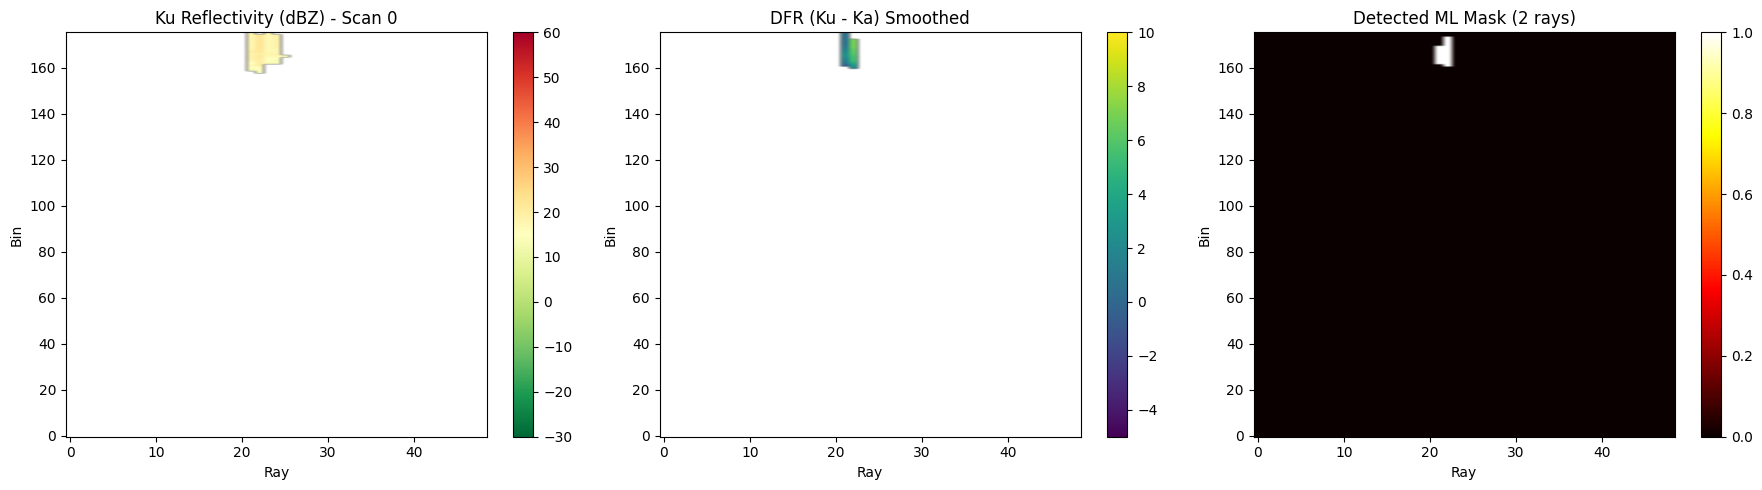


Scan 0 summary:
  Total rays: 49
  Rays with ML: 2
  Mean confidence: 0.760


In [18]:
# Visualize algorithm results for one scan
idx = 0
scan_mask = algo_masks[idx]
scan_confs = algo_confidences[idx]

# Re-read the data for this scan
with h5py.File(sel_file, 'r') as hf:
    zku_s, zka_s, h_km = read_scan(hf, idx)
    
    # Align Ka if needed (same logic as processing)
    if zka_s.shape[0] != zku_s.shape[0]:
        ka2d = np.transpose(zka_s, (1,0))
        ka2d = dgx.resample_rays_2d(ka2d, target_nray=zku_s.shape[0])
        zka_s = np.transpose(ka2d, (1,0))
    if zka_s.shape[1] != zku_s.shape[1]:
        nbin_ka = zka_s.shape[1]; nbin_ku = zku_s.shape[1]
        x_old = np.linspace(0.0, 1.0, num=nbin_ka)
        x_new = np.linspace(0.0, 1.0, num=nbin_ku)
        zka_res = np.empty((zka_s.shape[0], nbin_ku), dtype=zka_s.dtype)
        for r in range(zka_s.shape[0]):
            y = zka_s[r, :]
            m = np.isfinite(y)
            if m.sum() < 2:
                zka_res[r, :] = np.nan
            else:
                zka_res[r, :] = np.interp(x_new, x_old[m], y[m], left=y[m][0], right=y[m][-1])
        zka_s = zka_res
    
    # Compute DFR
    dfr = compute_dfr(zku_s, zka_s, smooth_win=algo_params['smooth_win'])
    
    # Transpose for visualization (nbin, nray)
    ku2d = np.transpose(zku_s, (1,0))
    dfr2d = np.transpose(dfr, (1,0))

fig, axs = plt.subplots(1, 3, figsize=(18,5))

# Ku reflectivity
im0 = axs[0].imshow(ku2d, origin='lower', aspect='auto', cmap='RdYlGn_r', 
                     vmin=data_cfg['MIN_VAL'], vmax=data_cfg['MAX_VAL'])
axs[0].set_title(f'Ku Reflectivity (dBZ) - Scan {idx}')
axs[0].set_xlabel('Ray'); axs[0].set_ylabel('Bin')
plt.colorbar(im0, ax=axs[0])

# DFR (Ku - Ka)
im1 = axs[1].imshow(dfr2d, origin='lower', aspect='auto', cmap='viridis', vmin=-5, vmax=10)
axs[1].set_title('DFR (Ku - Ka) Smoothed')
axs[1].set_xlabel('Ray'); axs[1].set_ylabel('Bin')
plt.colorbar(im1, ax=axs[1])

# Algorithm mask
im2 = axs[2].imshow(scan_mask, origin='lower', aspect='auto', cmap='hot', vmin=0, vmax=1)
axs[2].set_title(f'Detected ML Mask ({(scan_confs > 0).sum()} rays)')
axs[2].set_xlabel('Ray'); axs[2].set_ylabel('Bin')
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

# Print detection summary for this scan
print(f'\nScan {idx} summary:')
print(f'  Total rays: {len(scan_confs)}')
print(f'  Rays with ML: {(scan_confs > 0).sum()}')
print(f'  Mean confidence: {scan_confs[scan_confs > 0].mean():.3f}' if (scan_confs > 0).sum() > 0 else '  No detections')

In [19]:
# Save algorithm results to CSV
import csv

out_csv = 'algorithm_ml_detections.csv'
with open(out_csv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['file','scan_idx','nray','nbin','detections','mean_confidence'])
    writer.writeheader()
    for m in scan_metadata:
        row = {'file': os.path.basename(sel_file)}
        row.update(m)
        writer.writerow(row)

print(f'Saved {len(scan_metadata)} scan results to {out_csv}')

# Summary statistics
total_rays = sum(m['nray'] for m in scan_metadata)
total_detections = sum(m['detections'] for m in scan_metadata)
scans_with_ml = sum(1 for m in scan_metadata if m['detections'] > 0)

print(f'\nSummary:')
print(f'  Total scans: {len(scan_metadata)}')
print(f'  Scans with ML: {scans_with_ml} ({scans_with_ml/len(scan_metadata)*100:.1f}%)')
print(f'  Total rays: {total_rays}')
print(f'  Rays with ML: {total_detections} ({total_detections/total_rays*100:.1f}%)')

# Confidence distribution
all_confs = np.concatenate([c[c > 0] for c in algo_confidences if (c > 0).sum() > 0])
if len(all_confs) > 0:
    print(f'\nConfidence distribution:')
    print(f'  Min: {all_confs.min():.3f}')
    print(f'  Mean: {all_confs.mean():.3f}')
    print(f'  Max: {all_confs.max():.3f}')
else:
    print('\nNo detections across all scans')

Saved 50 scan results to algorithm_ml_detections.csv

Summary:
  Total scans: 50
  Scans with ML: 8 (16.0%)
  Total rays: 2450
  Rays with ML: 23 (0.9%)

Confidence distribution:
  Min: 0.244
  Mean: 0.787
  Max: 1.000


In [ ]:
# Optional: Compare with GPM CSF bright-band labels
# This checks how the algorithm compares to the official GPM product

def load_csf_mask(hf, scan_idx):
    """Load GPM CSF bright-band mask for comparison"""
    flagBB = dgx.safe_load_dataset(hf, '/FS/CSF/flagBB')
    topBB = dgx.safe_load_dataset(hf, '/FS/CSF/binBBTop')
    bottomBB = dgx.safe_load_dataset(hf, '/FS/CSF/binBBBottom')
    
    if flagBB is None or topBB is None or bottomBB is None:
        return None
    
    nray = flagBB.shape[1]
    with h5py.File(sel_file, 'r') as temp_hf:
        z_ku = dgx.read_reflectivity_band(temp_hf, group='FS', ds_path='/SLV/zFactorFinal')
        nbin = z_ku.shape[2]
    
    mask = np.zeros((nbin, nray), dtype=np.uint8)
    for r in range(nray):
        if flagBB[scan_idx, r] == 1:
            t = int(topBB[scan_idx, r])
            b = int(bottomBB[scan_idx, r])
            if 0 <= t < nbin and 0 <= b < nbin and b >= t:
                mask[t:b+1, r] = 1
    return mask

# Compare first scan
with h5py.File(sel_file, 'r') as hf:
    csf_mask = load_csf_mask(hf, 0)

if csf_mask is not None:
    algo_mask = algo_masks[0]
    
    # Compute overlap metrics
    inter = np.logical_and(csf_mask, algo_mask).sum()
    union = np.logical_or(csf_mask, algo_mask).sum()
    iou = inter / (union + 1e-9)
    dice = 2*inter / (csf_mask.sum() + algo_mask.sum() + 1e-9)
    
    print(f'Comparison with GPM CSF (Scan 0):')
    print(f'  IoU: {iou:.3f}')
    print(f'  Dice: {dice:.3f}')
    print(f'  CSF rays with BB: {(csf_mask.sum(axis=0) > 0).sum()}')
    print(f'  Algorithm rays with ML: {(algo_mask.sum(axis=0) > 0).sum()}')
else:
    print('CSF bright-band data not available')

Comparison with GPM CSF (Scan 0):
    IoU: 0.865
    Dice: 927.000
